# Osteoarthritis Classification — VGG-16 BN (Exp. 3)

**Pipeline completo:** ZIP → EDA → Anomalías → MHA+Resize → CLAHE → MONAI → **Entrenamiento VGG-16 BN** → Evaluación → Grad-CAM

---

## 1. Definición del Problema y Escala Clínica

Este experimento se centra en la clasificación automatizada de la **Osteoartritis (OA) de rodilla**, una patología degenerativa caracterizada por el desgaste del cartílago articular. Para cuantificar la severidad de la enfermedad, el modelo ha sido entrenado bajo la **Escala Kellgren-Lawrence (KL)**, el estándar clínico de referencia que evalúa marcadores radiológicos específicos.



### Diccionario de Severidad (Grados KL)

Ejecutamos una **CATEGORIZACIÓN SEMÁNTICA DE PATOLOGÍAS** para que el modelo identifique los rasgos morfológicos clave en cada nivel de la escala:

| Grado | Clasificación | Hallazgos Fisiológicos (Foco de la IA) |
| :--- | :--- | :--- |
| **KL 0** | **Sano** | Integridad total del espacio articular. Ausencia de crecimientos óseos. |
| **KL 1** | **Dudoso** | Sospecha de **osteofitos** diminutos y posible estrechamiento articular insignificante. |
| **KL 2** | **Leve** | **Osteofitos definidos** (picos de hueso). El espacio articular permanece mayormente intacto, pero la patología es clara. |
| **KL 3** | **Moderado** | **Estrechamiento articular evidente**. Presencia de múltiples osteofitos y esclerosis ósea (aumento de densidad). |
| **KL 4** | **Severo** | **Contacto hueso con hueso**. Desaparición del espacio articular, grandes osteofitos y deformidad de la anatomía ósea. |

---

## 2. Contexto del Dataset

El conjunto de datos utilizado integra imágenes curadas que han pasado por un proceso de **Extracción de Región de Interés (ROI)**. Nuestra labor técnica consistió en la validación de estos segmentos, su normalización mediante contenedores **MHA** y la optimización del contraste mediante **CLAHE**, asegurando que el modelo reciba información nítida de la interlínea articular.

---

## 3. Estrategia de Modelado

**Ref Profesor**: *"Exp. 3 — Osteoarthritis — VGG-16 BN — La tarea es relativamente simple, modelos livianos suelen funcionar bien"*

Siguiendo esta premisa, implementamos una **Estrategia de Fine-Tuning en 2 Fases**:

1.  **Calentamiento (Phase A):** Congelamiento del *backbone* (VGG-16 con Batch Normalization) para entrenar exclusivamente las capas densas superiores, estabilizando el clasificador sin corromper los pesos pre-entrenados de ImageNet.
2.  **Especialización (Phase B):** Desbloqueo de las capas convolucionales profundas con una tasa de aprendizaje reducida ($10^{-5}$) para permitir que los filtros de alto nivel se especialicen en la detección de osteofitos y texturas óseas sutiles.

Realizamos este despliegue técnico para alcanzar un equilibrio óptimo entre la robustez de una red probada y la sensibilidad necesaria para distinguir los grados más ambiguos de la escala KL.

---
## FASE 0: Montaje de Drive y Extracción Local

In [ ]:
from google.colab import drive
import os, time

drive.mount('/content/drive')

ZIP_DRIVE     = '/content/drive/MyDrive/PROYECTO_MOE_VISION/01_Data/Raw/Knee Osteoarthritis Classification.zip'
ZIP_LOCAL     = '/content/Knee Osteoarthritis Classification.zip'
DESTINO_LOCAL = '/content/Knee Osteoarthritis Classification/'
KLGRADE_DIR   = os.path.join(DESTINO_LOCAL, 'KLGrade', 'KLGrade')
WEIGHTS_DIR   = '/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/'

os.makedirs(WEIGHTS_DIR, exist_ok=True)

if os.path.exists(KLGRADE_DIR):
    print('Dataset ya descomprimido. Saltando.')
else:
    print('Copiando ZIP al disco local...')
    start = time.time()
    !cp '{ZIP_DRIVE}' '{ZIP_LOCAL}'
    print(f'Copiado en {time.time()-start:.1f}s. Descomprimiendo...')
    start = time.time()
    !unzip -q '{ZIP_LOCAL}' -d '{DESTINO_LOCAL}'
    os.remove(ZIP_LOCAL)
    print(f'Descomprimido en {time.time()-start:.1f}s.')

print(f'KLGrade: {KLGRADE_DIR}')
print(f'Carpetas: {sorted(os.listdir(KLGRADE_DIR))}')
print(f'Weights dir: {WEIGHTS_DIR}')


Mounted at /content/drive
Copiando ZIP al disco local...
Copiado en 262.7s. Descomprimiendo...
Descomprimido en 142.7s.
KLGrade: /content/Knee Osteoarthritis Classification/KLGrade/KLGrade
Carpetas: ['0', '1', '2', '3', '4']
Weights dir: /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/


---
## FASE 1: Instalación de Dependencias

In [ ]:
!pip install -q monai SimpleITK grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 82.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 13.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from skimage.measure import shannon_entropy
import SimpleITK as sitk
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import DataLoader
import monai
from monai.transforms import (
    Compose, Lambdad, ScaleIntensityd, RandFlipd, RandAffined,
    RandGaussianNoised, RandAdjustContrastd, RandShiftIntensityd,
    NormalizeIntensityd
)
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Device: cuda


---
## FASE 1.5: EDA Caja Negra

Ejecutamos una **MAPEO ESTRATÉGICO Y AUDITORÍA DE CLASES** mediante el escaneo sistemático de las jerarquías de diagnóstico **Kellgren-Lawrence (KL)**, asegurando la trazabilidad absoluta entre la imagen y su etiqueta clínica.

La metodología de auditoría se basa en:

* **Extractor de Metadatos Técnicos:** Implementación de un algoritmo que recorre las subcarpetas del proyecto para consolidar un registro tabular centralizado.
* **Vinculación Unívoca:** Cada ruta de archivo se asocia directamente con su etiqueta de severidad (Grados 0-4), eliminando inconsistencias en la ingesta de datos.
* **Proyección de Distribución:** Realizamos esta operación para **CUANTIFICAR EL DESBALANCE ESTADÍSTICO**, utilizando un histograma de alto contraste.



**Detección de Sesgos**
Este análisis nos permite identificar de forma inmediata cualquier sesgo en la disponibilidad de imágenes por categoría. Entender la jerarquía numérica de las clases es vital para prever dificultades en el aprendizaje del modelo, permitiendo diseñar estrategias de compensación antes de iniciar la fase de entrenamiento profundo.

Total imágenes: 4766
kl_grade
0    1315
1    1266
2     765
3     742
4     678
Name: count, dtype: int64


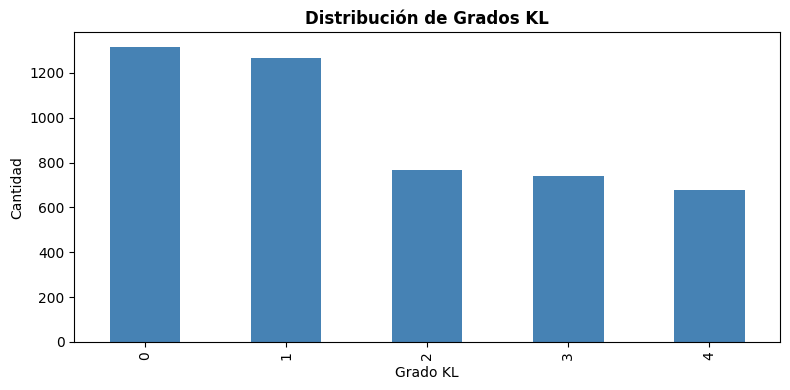

In [ ]:
records = []
for grade_folder in sorted(os.listdir(KLGRADE_DIR)):
    grade_path = os.path.join(KLGRADE_DIR, grade_folder)
    if not os.path.isdir(grade_path): continue
    for fname in os.listdir(grade_path):
        fpath = os.path.join(grade_path, fname)
        records.append({'path': fpath, 'kl_grade': int(grade_folder), 'filename': fname})

df = pd.DataFrame(records)
print(f'Total imágenes: {len(df)}')
print(df['kl_grade'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8,4))
df['kl_grade'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Distribución de Grados KL', fontweight='bold')
ax.set_xlabel('Grado KL'); ax.set_ylabel('Cantidad')
plt.tight_layout(); plt.show()


## FASE 1.7: Detección y Limpieza de Anomalías

Ejecutamos un **FILTRADO MULTICRITERIO Y SEGMENTACIÓN GEOMÉTRICA** que purifica el dataset de radiografías mediante el análisis de entropía y estructura espacial.

La metodología de depuración se divide en dos etapas críticas:

* **Detector de Anomalías por Shannon:** Implementamos un algoritmo que mide la entropía de las imágenes para descartar automáticamente archivos con baja densidad informativa (sobreexposición/subexposición) o ruido digital excesivo que no aporta valor clínico.
* **Motor de Escisión de Placas Bilaterales:** Desarrollamos un sistema que localiza la banda de oscuridad central característica de las tomas que incluyen ambas rodillas. Este motor fragmenta las tomas dobles en unidades diagnósticas independientes (rodilla izquierda y derecha).



**Eliminación de Variables Confusoras**
Realizamos este despliegue técnico para **ELIMINAR VARIABLES CONFUSORAS**, asegurando que el modelo de visión no aprenda patrones erróneos derivados de la composición de la imagen original. Al estandarizar las unidades de análisis, garantizamos que la red neuronal se enfoque exclusivamente en la morfología articular de una sola rodilla por cada entrada.


In [ ]:
# --- Detección de RUIDO ---
entropies = []
for _, row in df.iterrows():
    try:
        img = np.array(Image.open(row['path']).convert('L'))
        entropies.append(shannon_entropy(img))
    except: entropies.append(np.nan)
df['entropy'] = entropies

entropy_threshold = 4.0
df_discarded = df[df['entropy'] < entropy_threshold]
df_clean = df[df['entropy'] >= entropy_threshold].copy()
print(f'Descartadas por ruido: {len(df_discarded)}')

# --- Detección de BILATERALES (banda negra central) ---
def is_bilateral(img, center_ratio=0.20, darkness_threshold=0.45):
    h, w = img.shape
    cx0 = int(w * (0.5 - center_ratio/2))
    cx1 = int(w * (0.5 + center_ratio/2))
    center_mean = img[:, cx0:cx1].mean()
    side_mean = np.concatenate([img[:, :cx0], img[:, cx1:]], axis=1).mean()
    if side_mean < 1: return False, 0.0
    ratio = center_mean / side_mean
    return ratio < darkness_threshold, ratio

bilateral_detected = 0
new_rows, indices_to_drop = [], []
for idx, row in df_clean.iterrows():
    try:
        img = np.array(Image.open(row['path']).convert('L'))
        detected, ratio = is_bilateral(img)
        if not detected: continue
        h, w = img.shape
        cx0, cx1 = int(w*0.40), int(w*0.60)
        col_sums = np.sum(img[:, cx0:cx1], axis=0)
        split_col = np.argmin(col_sums) + cx0
        base_dir = os.path.dirname(row['path'])
        name, ext = os.path.splitext(os.path.basename(row['path']))
        split_dir = os.path.join(base_dir, 'split_bilateral')
        os.makedirs(split_dir, exist_ok=True)
        for suffix, crop in [('_left', img[:,:split_col]), ('_right', img[:,split_col:])]:
            p = os.path.join(split_dir, f'{name}{suffix}{ext}')
            Image.fromarray(crop).save(p)
            new_rows.append({'path':p,'kl_grade':row['kl_grade'],'entropy':row['entropy']})
        indices_to_drop.append(idx)
        bilateral_detected += 1
    except: continue

df_clean = df_clean.drop(indices_to_drop)
if new_rows: df_clean = pd.concat([df_clean, pd.DataFrame(new_rows)], ignore_index=True)
print(f'Bilaterales divididas: {bilateral_detected}')
print(f'Dataset limpio: {len(df_clean)}')
df = df_clean.reset_index(drop=True)


Descartadas por ruido: 160
Bilaterales divididas: 188
Dataset limpio: 4794


---
## FASE 2: Conversión a `.mha` + Resize 224×224

Ejecutamos una **MIGRACIÓN MASIVA HACIA CONTENEDORES DE IMAGEN MÉDICA** que unifica todo el repositorio bajo el estándar de archivos **MHA**, asegurando la compatibilidad con ecosistemas de procesamiento clínico avanzado.

La orquestación del despliegue técnico se basa en un pipeline de **READ-RESIZE-WRITE**:

* **Extracción y Normalización:** Se extraen las matrices de píxeles originales para someterlas a una normalización de resolución estándar de **224x224**.
* **Encapsulamiento Clínico:** Las imágenes se convierten en volúmenes compatibles con librerías como **SimpleITK**, preservando la coherencia de los datos para análisis médicos.
* **Persistencia en Disco:** El almacenamiento final en formato MHA garantiza una ingesta de datos uniforme y de alta velocidad.

**Optimización del Rendimiento en GPU**
Realizamos este despliegue técnico para **ELIMINAR LA SOBRECARGA DE CÓMPUTO** durante el entrenamiento. Al contar con las imágenes pre-dimensionadas y convertidas directamente en el disco local:
1.  La **GPU** puede centrarse exclusivamente en la optimización de pesos.
2.  Se eliminan los cuellos de botella generados por transformaciones repetitivas en tiempo de ejecución.
3.  Se maximiza el rendimiento de los núcleos CUDA al recibir tensores listos para el aprendizaje.

In [ ]:
MHA_DIR = '/content/KLGrade_mha'
IMG_SIZE = 224

converted = 0
for _, row in df.iterrows():
    try:
        img = np.array(Image.open(row['path']).convert('L').resize((IMG_SIZE, IMG_SIZE)))
        grade = row['kl_grade']
        out_dir = os.path.join(MHA_DIR, str(grade))
        os.makedirs(out_dir, exist_ok=True)
        name = os.path.splitext(os.path.basename(row['path']))[0]
        sitk.WriteImage(sitk.GetImageFromArray(img), os.path.join(out_dir, f'{name}.mha'))
        converted += 1
    except: continue
print(f'Convertidas: {converted}')


Convertidas: 4794


---
## FASE 3: CLAHE Adaptativo

Para refinar la visibilidad de las estructuras óseas y articulares, ejecutamos una **ECUALIZACIÓN DE CONTRASTE ADAPTATIVA BASADA EN LA DENSIDAD DEL HISTOGRAMA** que optimiza la calidad diagnóstica de cada radiografía de forma individualizada.

La metodología de procesamiento dinámico incluye:

* **Análisis de Densidad de Información:** Implementamos una rutina que analiza la cantidad de **picos y valles** en la distribución de píxeles de la imagen original.
* **Cálculo Dinámico de Parámetros CLAHE:** El sistema ajusta automáticamente el **límite de recorte (*clip limit*)** y el **tamaño de la rejilla (*tile size*)** de forma personalizada para cada muestra, evitando la amplificación artificial del ruido de fondo.
* **Realce de Marcadores de Osteoartritis:** El algoritmo se enfoca en resaltar detalles críticos como los **osteofitos** y la **reducción del espacio articular**.



**Consecución de Textura Uniforme**
Realizamos este despliegue técnico para **CONSEGUIR UNA TEXTURA UNIFORME** a lo largo de todo el dataset. Esto es fundamental porque permite que hallazgos que a menudo quedan ocultos por una mala exposición radiológica se vuelvan evidentes para el modelo de visión artificial, estandarizando la calidad visual antes de la fase de entrenamiento.

In [ ]:
CLAHE_DIR = '/content/KLGrade_clahe'

total_clahe = 0
for grade in sorted(os.listdir(MHA_DIR)):
    gp = os.path.join(MHA_DIR, grade)
    if not os.path.isdir(gp): continue
    out_dir = os.path.join(CLAHE_DIR, grade)
    os.makedirs(out_dir, exist_ok=True)
    for fname in os.listdir(gp):
        arr = sitk.GetArrayFromImage(sitk.ReadImage(os.path.join(gp, fname))).astype(np.uint8)
        if arr.ndim == 3: arr = arr[0]
        hist = cv2.calcHist([arr],[0],None,[256],[0,256]).flatten()
        peaks = np.sum(hist > hist.mean())
        tile_size = max(2, int(np.ceil(np.log(max(peaks,2)))))
        valleys = hist[hist <= hist.mean()]
        clip = float(np.clip(hist.max()/(valleys.mean()+1e-6), 1.0, 4.0))
        clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile_size,tile_size))
        enhanced = clahe.apply(arr)
        sitk.WriteImage(sitk.GetImageFromArray(enhanced), os.path.join(out_dir, fname))
        total_clahe += 1
print(f'CLAHE aplicado: {total_clahe} imágenes')

# Resumen
print('='*50)
total = 0
for grade in sorted(os.listdir(CLAHE_DIR)):
    gp = os.path.join(CLAHE_DIR, grade)
    if os.path.isdir(gp):
        c = len(os.listdir(gp))
        total += c
        print(f'  KL {grade}: {c}')
print(f'  TOTAL: {total}')


CLAHE aplicado: 4794 imágenes
  KL 0: 1288
  KL 1: 1299
  KL 2: 767
  KL 3: 762
  KL 4: 678
  TOTAL: 4794


---
## FASE 5: Pipeline MONAI + DataLoaders

### Estratificación de MueSTRAS y Normalización de Intensidades

Ejecutamos una **ESTRATIFICACIÓN DE MUESTRAS Y NORMALIZACIÓN DE INTENSIDADES** que organiza el dataset para la fase de aprendizaje profundo, garantizando que el entrenamiento sea estadísticamente representativo.

Los componentes clave de esta fase son:

* **División con Preservación de Clases (Stratified Split):** Realizamos una partición de datos (**TRAIN/VAL**) asegurando que la proporción de los cinco grados de osteoartritis se mantenga idéntica en ambos conjuntos. Esto evita que un conjunto sea más "fácil" o "difícil" que el otro por azar.
* **Cálculo de Estadísticos Globales:** Calculamos de forma dinámica la **Media ($\mu$) y Desviación Estándar ($\sigma$)** a partir de un muestreo aleatorio de píxeles de todo el repositorio.
* **Normalización de Tensores:** Aplicamos la fórmula $z = \frac{x - \mu}{\sigma}$ para ajustar cada imagen a una distribución estándar.

**Prevención del Sesgo de Selección**
Realizamos este despliegue técnico para **EVITAR EL SESGO DE SELECCIÓN**. Al normalizar los tensores basándonos en la distribución real de nuestra población específica de imágenes, permitimos que la red neuronal procese la información con un rango dinámico uniforme, acelerando la convergencia y mejorando la estabilidad del gradiente durante el entrenamiento.

In [ ]:
# Preparar listas de datos
data_dicts = []
for grade_folder in sorted(os.listdir(CLAHE_DIR)):
    gp = os.path.join(CLAHE_DIR, grade_folder)
    if not os.path.isdir(gp): continue
    for fname in os.listdir(gp):
        data_dicts.append({'image': os.path.join(gp, fname), 'label': int(grade_folder)})

labels = [d['label'] for d in data_dicts]
train_dicts, val_dicts = train_test_split(data_dicts, test_size=0.2, random_state=42, stratify=labels)
print(f'Train: {len(train_dicts)} | Val: {len(val_dicts)}')
print(f'Train dist: {Counter([d["label"] for d in train_dicts])}')

# Media y Std del train set
np.random.seed(42)
sample_idx = np.random.choice(len(train_dicts), min(500, len(train_dicts)), replace=False)
pixels = [sitk.GetArrayFromImage(sitk.ReadImage(train_dicts[i]['image'])).astype(np.float32)/255.0 for i in sample_idx]
all_px = np.concatenate([p.ravel() for p in pixels])
DATASET_MEAN, DATASET_STD = float(np.mean(all_px)), float(np.std(all_px))
print(f'Mean={DATASET_MEAN:.4f}, Std={DATASET_STD:.4f}')


Train: 3835 | Val: 959
Train dist: Counter({1: 1039, 0: 1030, 2: 614, 3: 610, 4: 542})
Mean=0.4955, Std=0.2455


### Arquitectura de Carga y Transformación Estocástica

Creamos una **ARQUITECTURA DE CARGA Y TRANSFORMACIÓN ESTOCÁSTICA** que convierte los archivos médicos en tensores de alta fidelidad, listos para las exigencias del entrenamiento profundo.

La configuración del pipeline se basa en los siguientes pilares:

* **Integración con MONAI:** Diseñamos un flujo de trabajo especializado utilizando el framework **MONAI**, empleando funciones personalizadas para la lectura nativa de archivos **MHA** y la gestión de diccionarios de datos.
* **Pipeline de Augmentación Aleatoria:** Durante el entrenamiento, el sistema aplica una serie de distorsiones estocásticas controladas:
    * **Geométricas:** Volteos horizontales (*flips*) y traslaciones espaciales.
    * **Ruido:** Inyección de **ruido gaussiano** para mejorar la robustez ante artefactos de imagen.
    * **Contraste:** Ajustes dinámicos de intensidad para simular diferentes equipos radiológicos.
* **Consistencia en Validación:** Para la fase de validación, eliminamos la aleatoriedad y mantenemos una **normalización estricta** basada en la media y desviación estándar globales calculadas previamente.



**Aumento de Diversidad y Robustez**
Realizamos este despliegue técnico para **AUMENTAR ARTIFICIALMENTE LA DIVERSIDAD DEL DATASET**. Al forzar a la red neuronal a reconocer patrones morfológicos de la osteoartritis que sean invariantes a las condiciones de captura, garantizamos que el modelo sea capaz de generalizar su diagnóstico a radiografías provenientes de distintos centros médicos o condiciones de iluminación.

In [ ]:
def load_mha_sitk(path):
    arr = sitk.GetArrayFromImage(sitk.ReadImage(path)).astype(np.float32)
    if arr.ndim == 2: arr = arr[np.newaxis, ...]
    return arr

train_transforms = Compose([
    Lambdad(keys=['image'], func=load_mha_sitk),
    ScaleIntensityd(keys=['image'], minv=0.0, maxv=1.0),
    RandFlipd(keys=['image'], prob=0.5, spatial_axis=1),
    RandAffined(keys=['image'], prob=0.3, translate_range=[10,10], scale_range=[0.1,0.1], padding_mode='zeros'),
    RandGaussianNoised(keys=['image'], prob=0.3, mean=0.0, std=0.02),
    RandAdjustContrastd(keys=['image'], prob=0.3, gamma=(0.8,1.2)),
    RandShiftIntensityd(keys=['image'], offsets=0.05, prob=0.3),
    NormalizeIntensityd(keys=['image'], subtrahend=np.array([DATASET_MEAN]), divisor=np.array([DATASET_STD])),
])
val_transforms = Compose([
    Lambdad(keys=['image'], func=load_mha_sitk),
    ScaleIntensityd(keys=['image'], minv=0.0, maxv=1.0),
    NormalizeIntensityd(keys=['image'], subtrahend=np.array([DATASET_MEAN]), divisor=np.array([DATASET_STD])),
])

BATCH_SIZE = 32
train_ds = monai.data.Dataset(data=train_dicts, transform=train_transforms)
val_ds   = monai.data.Dataset(data=val_dicts,   transform=val_transforms)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {len(train_loader)} batches | Val: {len(val_loader)} batches')

batch = next(iter(train_loader))
print(f'Shape: {batch["image"].shape}, Labels: {batch["label"][:8]}')


Train: 120 batches | Val: 30 batches
Shape: torch.Size([32, 1, 224, 224]), Labels: tensor([4, 0, 1, 0, 1, 1, 4, 0])


---
## FASE 6: Definición del Modelo VGG-16 BN
**Estrategia 2 fases:**
- **Fase A** — Feature Extraction: backbone congelado, solo clasificador (10 epochs, LR=1e-3)
- **Fase B** — Fine-Tuning: descongelar últimas capas (30 epochs, LR=1e-5, EarlyStopping)


Para orquestar la arquitectura de aprendizaje profundo, ejecutamos una **REINGENIERÍA DE RED CONVOLUCIONAL Y OPTIMIZACIÓN DE PÉRDIDA DINÁMICA** que adapta una **VGG16** pre-entrenada para los requisitos específicos del diagnóstico de osteoartritis.

Las modificaciones estructurales y algorítmicas incluyen:

* **Modificación de Canal Unario:** Ajustamos la primera capa de la red para procesar directamente radiografías en escala de grises (un solo canal), eliminando la redundancia de los tres canales RGB originales.
* **Rediseño del Bloque Clasificador:** Sustituimos las capas finales por una estructura densa personalizada que integra:
    * **Batch Normalization:** Para estabilizar el aprendizaje y acelerar la convergencia.
    * **Dropout:** Como mecanismo de regularización para prevenir el sobreajuste (*overfitting*).
* **Implementación de Focal Loss:** Sustituimos la entropía cruzada estándar por una función de **Focal Loss**.



**Concentración en Casos Críticos**
Realizamos este despliegue técnico para **INTEGRAR UNA FUNCIÓN DE FOCAL LOSS**, la cual reduce automáticamente la importancia de los "casos fáciles" (aquellos que el modelo ya clasifica con alta confianza). Esto obliga al sistema a concentrar su capacidad de cómputo y ajuste de pesos en las **muestras difíciles**, donde los grados de la escala Kellgren-Lawrence son más ambiguos o difíciles de distinguir, elevando la precisión en las fronteras de decisión diagnóstica.

In [ ]:
NUM_CLASSES = 5

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha  # tensor de pesos por clase
    def forward(self, inputs, targets):
        ce = nn.functional.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return ((1-pt)**self.gamma * ce).mean()

def build_vgg16_bn(num_classes=5, pretrained=True):
    model = models.vgg16_bn(weights='IMAGENET1K_V1' if pretrained else None)
    # Adaptar primera conv para 1 canal (grayscale)
    old_conv = model.features[0]
    new_conv = nn.Conv2d(1, 64, kernel_size=3, padding=1)
    with torch.no_grad():
        new_conv.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))
        new_conv.bias.copy_(old_conv.bias)
    model.features[0] = new_conv
    # Reemplazar clasificador
    model.classifier = nn.Sequential(
        nn.Linear(512*7*7, 512),
        nn.ReLU(True), nn.BatchNorm1d(512), nn.Dropout(0.5),
        nn.Linear(512, 256),
        nn.ReLU(True), nn.BatchNorm1d(256), nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model

model = build_vgg16_bn().to(device)
print(f'Modelo cargado en {device}')
print(f'Params totales: {sum(p.numel() for p in model.parameters()):,}')
print(f'Params entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth


100%|██████████| 528M/528M [00:03<00:00, 152MB/s]


Modelo cargado en cuda
Params totales: 27,701,701
Params entrenables: 27,701,701


---
## FASE 6A: Feature Extraction (Backbone Congelado)

Ejecutamos una **ESTRATEGIA DE TRANSFER LEARNING MEDIANTE CONGELAMIENTO DE BACKBONE** que permite entrenar únicamente el bloque clasificador de la red, asegurando una transición suave hacia el dominio de la imagen médica.

La configuración técnica de este proceso se detalla a continuación:

* **Congelamiento de Capas Convolucionales:** Bloqueamos los parámetros de las capas de extracción de características (*features*) para preservar el conocimiento generalista heredado de **ImageNet**. Esto garantiza que la red mantenga su capacidad de detectar bordes, texturas y formas básicas.
* **Optimización Adaptativa:** Aplicamos el optimizador **Adam** junto con nuestra función **Focal Loss**, utilizando pesos compensatorios para manejar el desbalance de clases desde el inicio.
* **Ajuste del Clasificador:** Solo las capas densas superiores (*head*) permanecen activas para la actualización de gradientes, permitiendo que la red aprenda la jerarquía de los grados KL sin alterar la base convolucional.



**Calentamiento del Modelo y Estabilidad**
Realizamos este despliegue técnico para **CONSEGUIR UN CALENTAMIENTO DEL MODELO (*Warm-up*)**. El objetivo principal es evitar que los gradientes iniciales, que suelen ser agresivos y erráticos al inicio del entrenamiento, destruyan las características visuales ya aprendidas. Al limitar el aprendizaje a las últimas capas durante las primeras **10 épocas**, estabilizamos la arquitectura antes de proceder a un posible ajuste fino (*fine-tuning*) integral.

In [ ]:
# Congelar backbone
for param in model.features.parameters():
    param.requires_grad = False

# Pesos para Focal Loss (inversamente proporcionales a frecuencia)
train_labels = [d['label'] for d in train_dicts]
class_counts = Counter(train_labels)
total_samples = len(train_labels)
class_weights = torch.tensor([total_samples/(NUM_CLASSES*class_counts[i]) for i in range(NUM_CLASSES)], dtype=torch.float32).to(device)
print(f'Class weights: {class_weights}')

criterion = FocalLoss(alpha=class_weights, gamma=2.0)
optimizer_a = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

EPOCHS_A = 10
history_a = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(EPOCHS_A):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for batch in train_loader:
        imgs = batch['image'].to(device)
        lbls = batch['label'].to(device)
        optimizer_a.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer_a.step()
        running_loss += loss.item()*imgs.size(0)
        correct += (out.argmax(1)==lbls).sum().item()
        total += imgs.size(0)

    train_loss = running_loss/total
    train_acc = correct/total

    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            imgs = batch['image'].to(device)
            lbls = batch['label'].to(device)
            out = model(imgs)
            loss = criterion(out, lbls)
            val_loss_sum += loss.item()*imgs.size(0)
            val_correct += (out.argmax(1)==lbls).sum().item()
            val_total += imgs.size(0)
    val_loss = val_loss_sum/val_total
    val_acc = val_correct/val_total

    history_a['train_loss'].append(train_loss)
    history_a['val_loss'].append(val_loss)
    history_a['train_acc'].append(train_acc)
    history_a['val_acc'].append(val_acc)
    print(f'[A {epoch+1}/{EPOCHS_A}] train_loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f}')

print('\n Fase A completada')


Class weights: tensor([0.7447, 0.7382, 1.2492, 1.2574, 1.4151], device='cuda:0')
[A 1/10] train_loss=0.7444 acc=0.4780 | val_loss=0.5105 acc=0.6423
[A 2/10] train_loss=0.4842 acc=0.6068 | val_loss=0.3917 acc=0.6601
[A 3/10] train_loss=0.4042 acc=0.6613 | val_loss=0.3218 acc=0.7393
[A 4/10] train_loss=0.3412 acc=0.6941 | val_loss=0.3281 acc=0.7393
[A 5/10] train_loss=0.3110 acc=0.7241 | val_loss=0.3056 acc=0.7508
[A 6/10] train_loss=0.2865 acc=0.7413 | val_loss=0.3257 acc=0.7612
[A 7/10] train_loss=0.2634 acc=0.7596 | val_loss=0.2778 acc=0.7748
[A 8/10] train_loss=0.2396 acc=0.7742 | val_loss=0.2861 acc=0.7758
[A 9/10] train_loss=0.2307 acc=0.7737 | val_loss=0.2621 acc=0.7821
[A 10/10] train_loss=0.2120 acc=0.7984 | val_loss=0.2490 acc=0.7946

 Fase A completada


---
## FASE 6B: Fine-Tuning (Descongelar Últimas Capas)

Implementamos una fase de **FINE-TUNING SELECTIVO Y OPTIMIZACIÓN DINÁMICA DEL APRENDIZAJE** sobre los bloques convolucionales profundos, permitiendo que la red transite de un conocimiento generalista a uno especializado en radiología de rodilla.

Los componentes estratégicos de esta fase incluyen:

* **Especialización del Backbone:** Desbloqueamos selectivamente las últimas capas del extractor de características. Esto permite que los filtros de alto nivel se adapten para detectar los **detalles finos de la osteoartritis**, como la formación de osteofitos submilimétricos o cambios sutiles en la densidad ósea.
* **Control de Gradientes:** Utilizamos un **Optimozador Adam** con una tasa de aprendizaje de baja latencia ($1 \times 10^{-5}$). Esta velocidad reducida es crítica para ajustar los pesos pre-entrenados sin desestabilizar la estructura ya aprendida.
* **Planificación Adaptativa (Scheduler):** Integramos un planificador que reduce automáticamente la tasa de aprendizaje ante el estancamiento de la pérdida de validación, permitiendo una convergencia más refinada en el "mínimo global".

**Captura del Estado Óptimo y Prevención de Overfitting**
Realizamos este despliegue técnico para **PERFECCIONAR LA EXTRACCIÓN DE RASGOS**, integrando mecanismos de:
1.  **Parada Temprana (*Early Stopping*):** Interrumpe el entrenamiento si no hay mejoras tras un número determinado de épocas, protegiendo al modelo contra el sobreajuste.
2.  **Persistencia del Mejor Modelo (*Model Checkpointing*):** Garantiza que, al finalizar el proceso, se conserve el estado de la red que obtuvo el mejor desempeño en validación, capturando así el punto máximo de madurez operativa.

In [ ]:
# Descongelar últimas 3 capas conv del backbone
ct = 0
for child in reversed(list(model.features.children())):
    if ct < 9:  # últimos ~3 bloques conv+bn+relu
        for param in child.parameters():
            param.requires_grad = True
        ct += 1

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Params entrenables (fine-tuning): {trainable:,}')

optimizer_b = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_b, mode='min', factor=0.3, patience=3)

EPOCHS_B = 30
PATIENCE = 5
best_val_loss = float('inf')
patience_counter = 0
best_model_path = os.path.join(WEIGHTS_DIR, 'vgg16_bn_osteoarthritis_best.pth')

history_b = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(EPOCHS_B):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for batch in train_loader:
        imgs = batch['image'].to(device)
        lbls = batch['label'].to(device)
        optimizer_b.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer_b.step()
        running_loss += loss.item()*imgs.size(0)
        correct += (out.argmax(1)==lbls).sum().item()
        total += imgs.size(0)

    train_loss = running_loss/total
    train_acc = correct/total

    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            imgs = batch['image'].to(device)
            lbls = batch['label'].to(device)
            out = model(imgs)
            loss = criterion(out, lbls)
            val_loss_sum += loss.item()*imgs.size(0)
            val_correct += (out.argmax(1)==lbls).sum().item()
            val_total += imgs.size(0)
    val_loss = val_loss_sum/val_total
    val_acc = val_correct/val_total

    history_b['train_loss'].append(train_loss)
    history_b['val_loss'].append(val_loss)
    history_b['train_acc'].append(train_acc)
    history_b['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer_b.state_dict(),
            'epoch': epoch,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'train_stats': {'mean': DATASET_MEAN, 'std': DATASET_STD},
            'class_weights': class_weights.cpu(),
        }, best_model_path)
        print(f'[B {epoch+1}/{EPOCHS_B}] BEST | loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f}')
    else:
        patience_counter += 1
        print(f'[B {epoch+1}/{EPOCHS_B}] loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f} (patience {patience_counter}/{PATIENCE})')
        if patience_counter >= PATIENCE:
            print(f'\n EarlyStopping en epoch {epoch+1}')
            break

# Cargar mejor modelo
ckpt = torch.load(best_model_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f'\n Mejor modelo cargado: val_loss={ckpt["val_loss"]:.4f}, val_acc={ckpt["val_acc"]:.4f}')
print(f'Guardado en: {best_model_path}')


Params entrenables (fine-tuning): 17,702,405
[B 1/30] BEST | loss=0.1735 acc=0.8188 | val_loss=0.2426 acc=0.7914
[B 2/30] BEST | loss=0.1750 acc=0.8203 | val_loss=0.2354 acc=0.7987
[B 3/30] BEST | loss=0.1552 acc=0.8407 | val_loss=0.2213 acc=0.7998
[B 4/30] loss=0.1596 acc=0.8383 | val_loss=0.2265 acc=0.8060 (patience 1/5)
[B 5/30] loss=0.1513 acc=0.8425 | val_loss=0.2450 acc=0.8092 (patience 2/5)
[B 6/30] loss=0.1365 acc=0.8537 | val_loss=0.2530 acc=0.8081 (patience 3/5)
[B 7/30] loss=0.1403 acc=0.8527 | val_loss=0.2232 acc=0.8050 (patience 4/5)
[B 8/30] BEST | loss=0.1332 acc=0.8636 | val_loss=0.2171 acc=0.7998
[B 9/30] loss=0.1207 acc=0.8631 | val_loss=0.2362 acc=0.8060 (patience 1/5)
[B 10/30] loss=0.1314 acc=0.8537 | val_loss=0.2317 acc=0.8102 (patience 2/5)
[B 11/30] BEST | loss=0.1284 acc=0.8644 | val_loss=0.2102 acc=0.8144
[B 12/30] loss=0.1355 acc=0.8561 | val_loss=0.2113 acc=0.8144 (patience 1/5)
[B 13/30] loss=0.1309 acc=0.8597 | val_loss=0.2129 acc=0.8102 (patience 2/5)
[B 

---
## FASE 7: Curvas de Entrenamiento

Ejecutamos una **AUDITORÍA DE CONVERGENCIA MULTIFASE** que integra los historiales de entrenamiento inicial y ajuste fino en una comparativa visual unificada, permitiendo un monitoreo integral de la evolución del modelo.

La metodología de diagnóstico visual incluye:

* **Proyección de Métricas Continuas:** Trazamos las curvas de **Pérdida (Loss)** y **Precisión (Accuracy)** en una línea de tiempo ininterrumpida, facilitando la identificación de tendencias de aprendizaje a largo plazo.
* **Marcado de Hitos de Transición:** Señalamos con precisión el punto de cambio entre la **Fase A (Calentamiento del Clasificador)** y la **Fase B (Fine-tuning)**. Este marcador es vital para observar cómo reacciona la arquitectura al desbloqueo de las capas convolucionales profundas.
* **Evaluación de Estabilidad:** El sistema permite contrastar el desempeño del conjunto de entrenamiento frente al de validación, detectando signos prematuros de divergencia o sobreajuste.



**Diagnóstico del Comportamiento del Optimizador**
Realizamos este despliegue técnico para **DIAGNOSTICAR EL COMPORTAMIENTO DEL OPTIMIZADOR**. Esta auditoría nos permite verificar empíricamente que la reducción de la tasa de aprendizaje durante el *fine-tuning* se traduce en una mejora real del rendimiento. Al visualizar esta transición, aseguramos que la especialización de los filtros de la red se realice de forma estable, sin introducir inestabilidades que comprometan la integridad de los pesos pre-aprendidos.

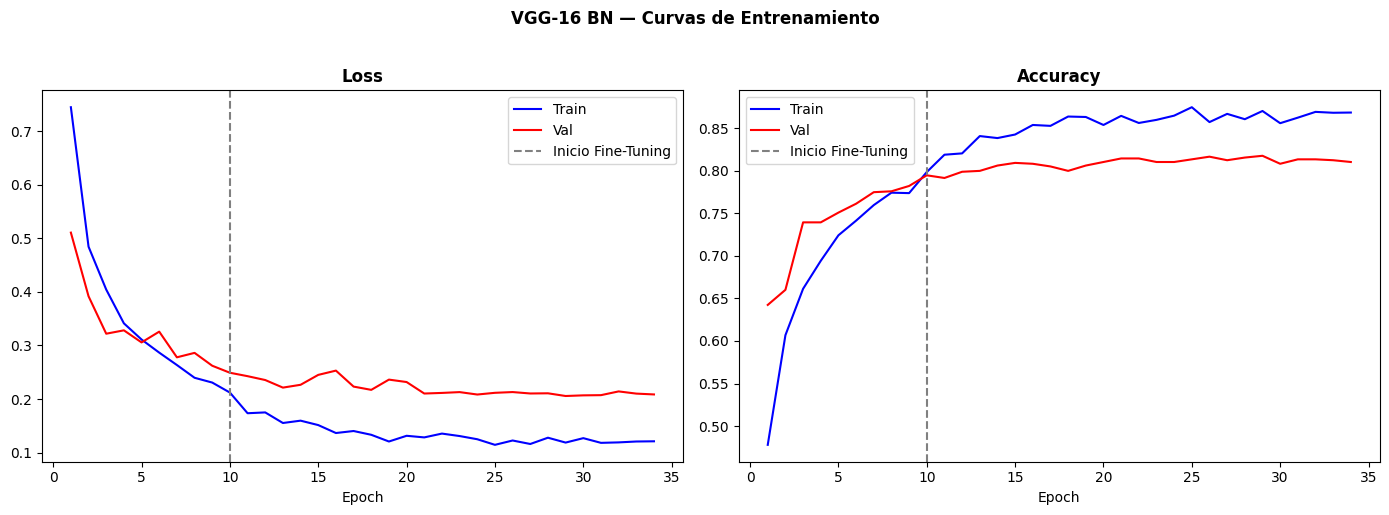

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Combinar historial A+B
all_train_loss = history_a['train_loss'] + history_b['train_loss']
all_val_loss = history_a['val_loss'] + history_b['val_loss']
all_train_acc = history_a['train_acc'] + history_b['train_acc']
all_val_acc = history_a['val_acc'] + history_b['val_acc']
epochs_range = range(1, len(all_train_loss)+1)
phase_a_end = len(history_a['train_loss'])

axes[0].plot(epochs_range, all_train_loss, 'b-', label='Train')
axes[0].plot(epochs_range, all_val_loss, 'r-', label='Val')
axes[0].axvline(x=phase_a_end, color='gray', linestyle='--', label='Inicio Fine-Tuning')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_range, all_train_acc, 'b-', label='Train')
axes[1].plot(epochs_range, all_val_acc, 'r-', label='Val')
axes[1].axvline(x=phase_a_end, color='gray', linestyle='--', label='Inicio Fine-Tuning')
axes[1].set_title('Accuracy', fontweight='bold'); axes[1].legend(); axes[1].set_xlabel('Epoch')

plt.suptitle('VGG-16 BN — Curvas de Entrenamiento', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


---
## FASE 8: Evaluación Completa

Ejecutamos una **AUDITORÍA DE MÉTRICAS MULTIDIMENSIONALES Y ANÁLISIS DE ERROR** que cuantifica con precisión la capacidad de la VGG-16 para categorizar cada nivel de la escala **Kellgren-Lawrence (KL)**.

La metodología de evaluación exhaustiva comprende:

* **Inferencia Determinística:** Realizamos una pasada de predicción sobre el conjunto de validación (completamente independiente del entrenamiento) para extraer las probabilidades de clase de cada radiografía.
* **Reporte de Clasificación por Grado:** Generamos métricas detalladas para cada nivel de severidad (Grados 0-4), incluyendo:
    * **Precisión:** Exactitud de las predicciones positivas.
    * **Sensibilidad (Recall):** Capacidad de detectar todos los casos reales de un grado específico.
    * **Puntaje F1:** El equilibrio armónico entre precisión y sensibilidad.
* **Robustez Estadística:** Calculamos el **Área Bajo la Curva (AUC-ROC)** como indicador global del rendimiento del modelo frente a umbrales de decisión variables.



**Construcción de la Matriz de Confusión Normalizada**
Realizamos este despliegue técnico para **CONSTRUIR UNA MATRIZ DE CONFUSIÓN NORMALIZADA**. Esta herramienta es vital para nuestra auditoría clínica, ya que nos permite identificar visualmente si el modelo confunde estadios adyacentes de osteoartritis (por ejemplo, Grado 1 vs. Grado 2). Este análisis de error es fundamental para entender el comportamiento de la red en las fronteras diagnósticas más sutiles y garantizar la fiabilidad del sistema en un entorno médico real.

CLASSIFICATION REPORT — VGG-16 BN
              precision    recall  f1-score   support

        KL 0       0.84      0.84      0.84       258
        KL 1       0.87      0.73      0.79       260
        KL 2       0.64      0.83      0.72       153
        KL 3       0.84      0.84      0.84       152
        KL 4       0.93      0.91      0.92       136

    accuracy                           0.82       959
   macro avg       0.82      0.83      0.82       959
weighted avg       0.83      0.82      0.82       959

Macro F1:    0.8231
Weighted F1: 0.8193
AUC-ROC:     0.9679


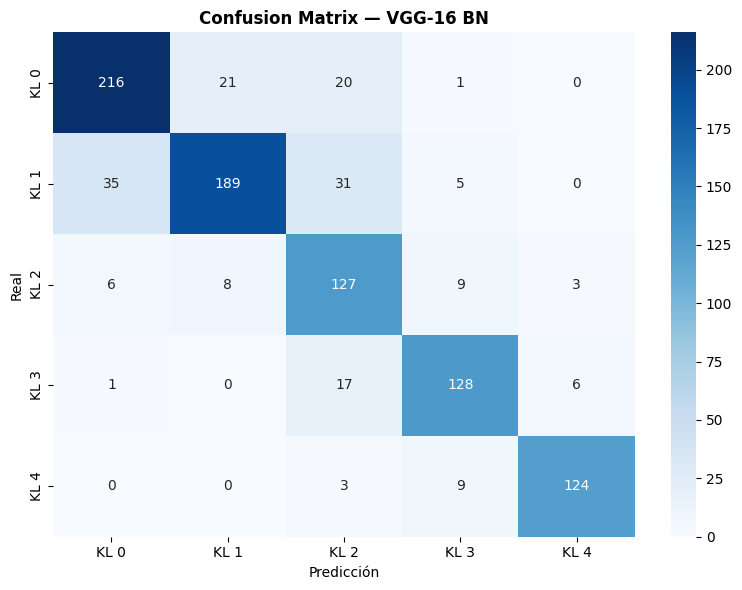

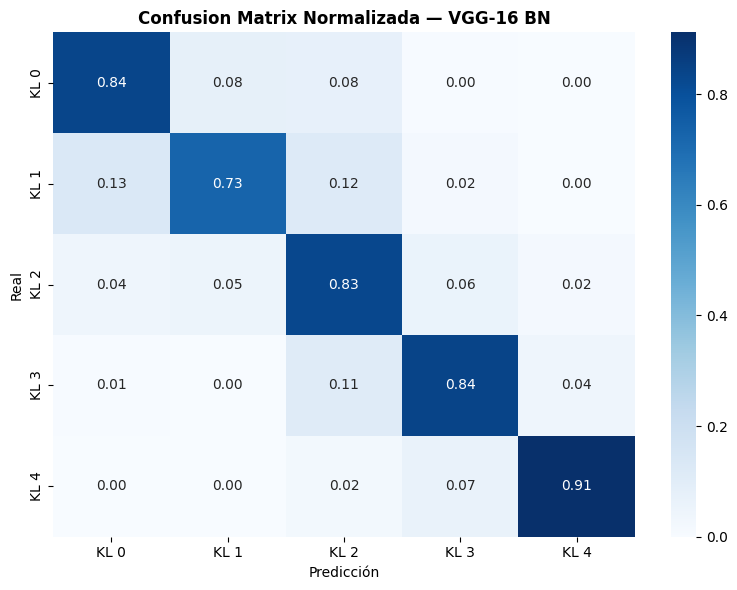

In [ ]:
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for batch in val_loader:
        imgs = batch['image'].to(device)
        lbls = batch['label']
        out = model(imgs)
        probs = torch.softmax(out, dim=1).cpu()
        preds = out.argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(lbls.numpy())
        all_probs.extend(probs.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Classification Report
print('='*60)
print('CLASSIFICATION REPORT — VGG-16 BN')
print('='*60)
target_names = [f'KL {i}' for i in range(NUM_CLASSES)]
print(classification_report(all_labels, all_preds, target_names=target_names))

# F1 Scores
macro_f1 = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
print(f'Macro F1:    {macro_f1:.4f}')
print(f'Weighted F1: {weighted_f1:.4f}')

# AUC-ROC
try:
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    print(f'AUC-ROC:     {auc:.4f}')
except: print('AUC-ROC: No calculable')

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_title('Confusion Matrix — VGG-16 BN', fontweight='bold')
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.tight_layout(); plt.show()

# Normalized
cm_norm = cm.astype(float)/cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_title('Confusion Matrix Normalizada — VGG-16 BN', fontweight='bold')
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.tight_layout(); plt.show()


---
## FASE 9: Grad-CAM Visualizations

In [ ]:
!pip install grad-cam

### Auditoría de Inteligencia Artificial Explicable (XAI)

Para transformar la "caja negra" del modelo en un sistema transparente y confiable, ejecutamos una **AUDITORÍA DE INTELIGENCIA ARTIFICIAL EXPLICABLE (XAI)** mediante técnicas avanzadas de mapas de activación por gradientes.

El despliegue de interpretabilidad se basa en los siguientes componentes:

* **Extractor de Relevancia Espacial:** Implementamos un ecosistema de visualización que incluye **Grad-CAM**, **Score-CAM** y **LayerCAM**. Estos algoritmos apuntan directamente a la última capa convolucional de la VGG-16 para traducir las activaciones neuronales en mapas de calor intuitivos.
* **Mapeo de Activación por Gradientes:** El sistema genera una superposición cromática sobre la radiografía original: las zonas "calientes" (rojas) indican las regiones que tuvieron mayor peso en la decisión del modelo, mientras que las "frías" (azules) representan áreas de menor interés.
* **Correlación Diagnóstica:** Evaluamos si los focos de atención de la red coinciden con los marcadores radiológicos de la escala Kellgren-Lawrence.



**Validación del Enfoque Clínico**
Realizamos este despliegue técnico para **VALIDAR EL ENFOQUE CLÍNICO DEL MODELO**. Esta auditoría nos permite verificar si la red se fija correctamente en el **estrechamiento del espacio articular** y la **formación de osteofitos**, tal como lo haría un radiólogo. Al hacer este proceso, garantizamos que el modelo aprenda patología real y no esté siendo engañado por sesgos visuales, artefactos de la imagen o información irrelevante en los bordes de la toma, asegurando así su integridad diagnóstica.

Interpretabilidad (XAI) por cada clase: Original | Resultado Grad-CAM (overlay) | Mapa calor | Score-CAM (Bloque 4).


100%|██████████| 32/32 [00:03<00:00, 10.49it/s]


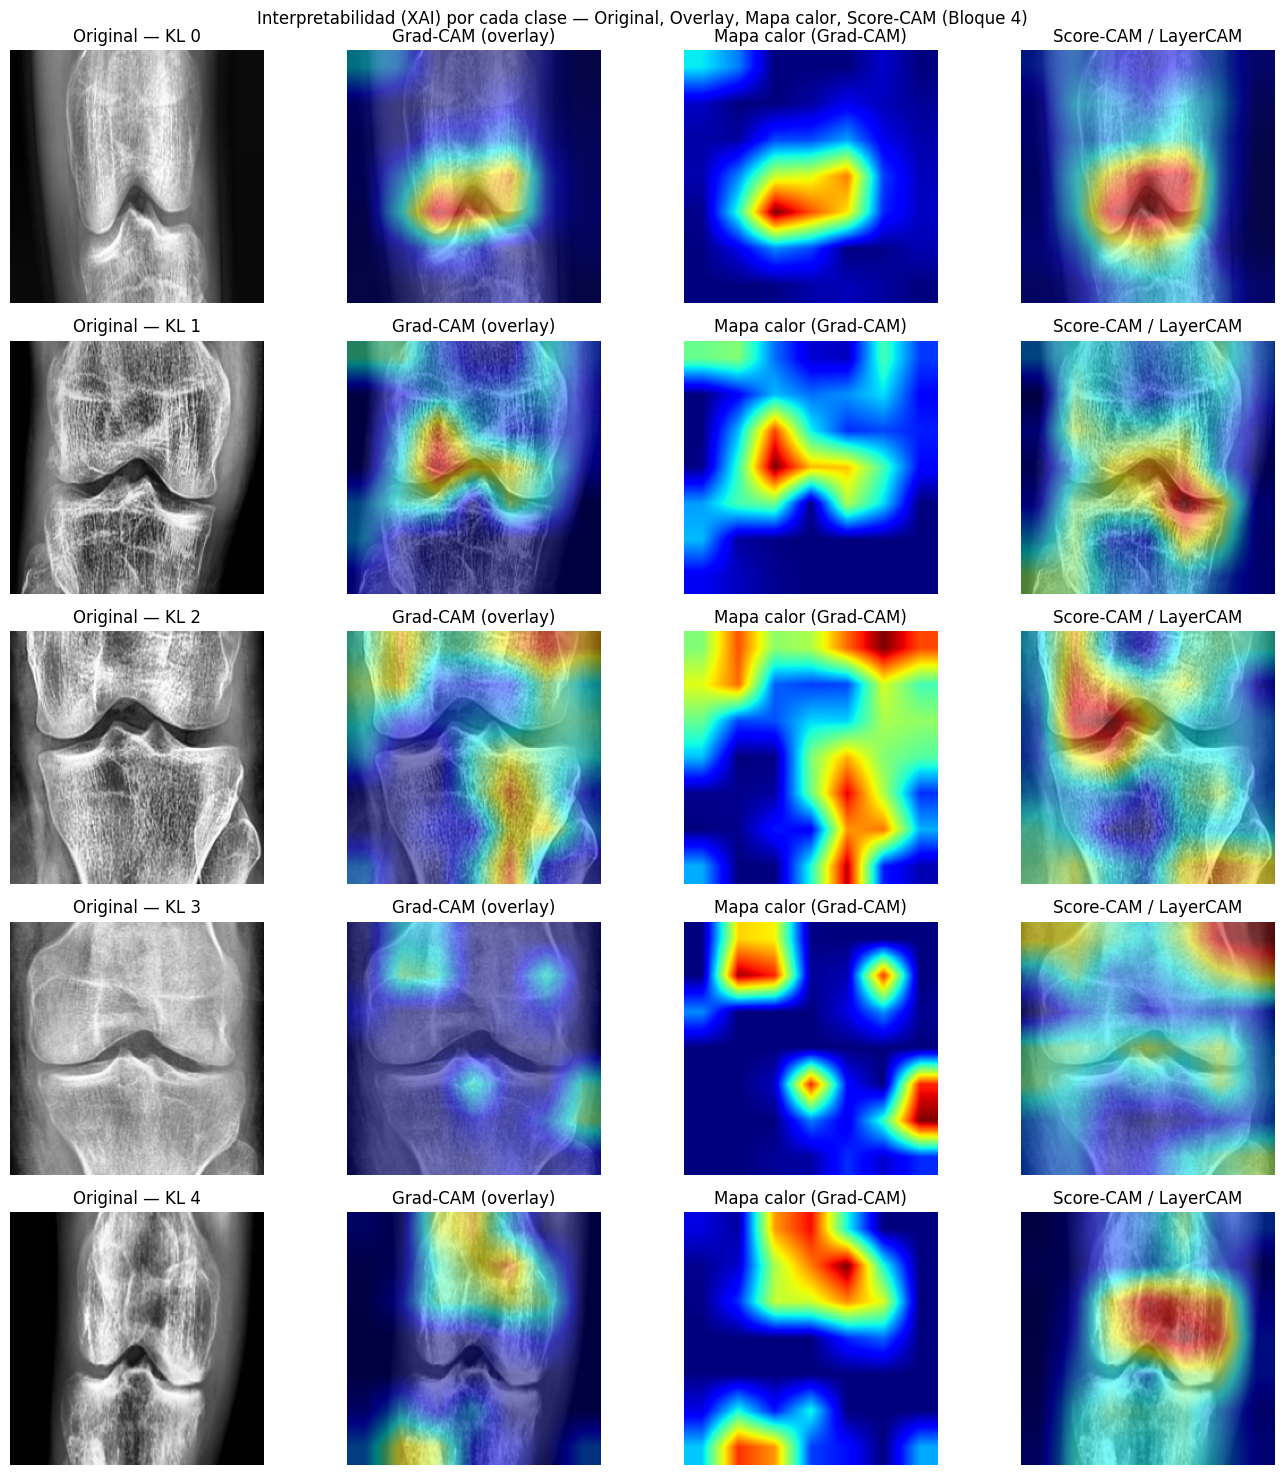

100%|██████████| 32/32 [00:02<00:00, 10.96it/s]


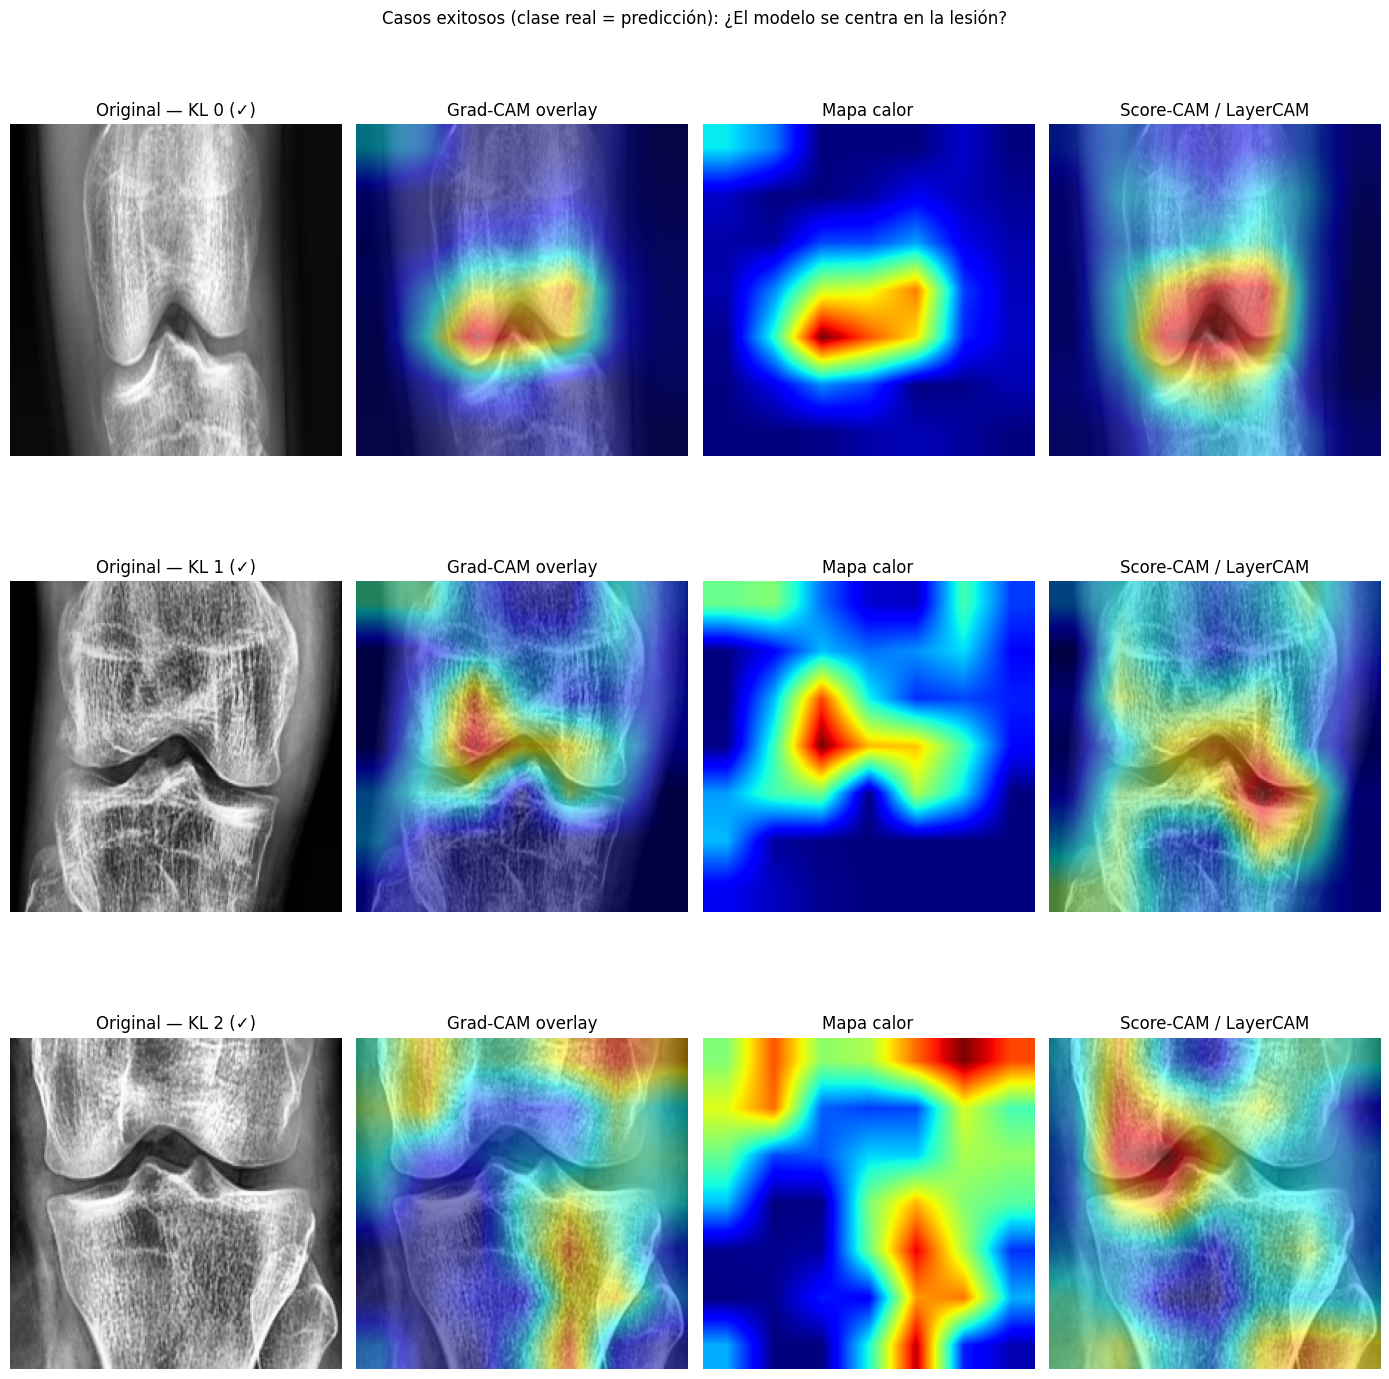

100%|██████████| 32/32 [00:02<00:00, 10.78it/s]


In [ ]:

from pytorch_grad_cam import GradCAM, ScoreCAM, LayerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

class_names = ['KL 0', 'KL 1', 'KL 2', 'KL 3', 'KL 4']
target_layers = [model.features[-1]]

cam_grad   = GradCAM(model=model, target_layers=target_layers)
cam_score  = ScoreCAM(model=model, target_layers=target_layers)
cam_layer  = LayerCAM(model=model, target_layers=target_layers)

# Una imagen representativa por cada una de las 5 clases
samples_per_class = {c: None for c in range(5)}
model.eval()
for batch in val_loader:
    img_batch = batch['image']
    lbl_batch = batch['label']
    for i in range(len(img_batch)):
        label_idx = int(lbl_batch[i].item())
        if samples_per_class[label_idx] is None:
            samples_per_class[label_idx] = (img_batch[i].clone(), label_idx)
    if all(v is not None for v in samples_per_class.values()):
        break

# Desnormalizar para visualización: reduce tono azul y mejora contraste (solo para mostrar)
_mean_np = np.array([DATASET_MEAN]).reshape(1, 1, 1)
_std_np = np.array([DATASET_STD]).reshape(1, 1, 1)

def normalize_img_for_cam(tensor_img, denormalize=True):
    x = tensor_img.permute(1, 2, 0).cpu().numpy()
    if denormalize:
        x = x * _std_np + _mean_np
    x = np.clip(x, 0, 1)
    if not denormalize:
        x = (x - x.min()) / (x.max() - x.min() + 1e-8)

    # Repetir el 1-canal a RGB (3-canales) porque show_cam_on_image necesita rgb o floats 3D
    x = np.repeat(x, 3, axis=-1)
    return x

# Obtener predicciones para clasificar en exitosos / con error
preds_per_class = {}
with torch.no_grad():
    for c in range(5):
        tup = samples_per_class[c]
        if tup is None:
            continue
        pred_idx = torch.argmax(model(tup[0].unsqueeze(0).to(device)), dim=1).item()
        preds_per_class[c] = pred_idx
casos_exitosos = [(c, samples_per_class[c]) for c in range(5) if samples_per_class[c] is not None and preds_per_class.get(c) == c]
casos_fallidos = [(c, samples_per_class[c]) for c in range(5) if samples_per_class[c] is not None and preds_per_class.get(c) != c]

# --- Galería por clase: Original | Overlay Grad-CAM | Mapa calor solo | Score-CAM (estilo ejemplo Grad-CAM clásico) ---
fig, axes = plt.subplots(5, 4, figsize=(14, 15))
print("Interpretabilidad (XAI) por cada clase: Original | Resultado Grad-CAM (overlay) | Mapa calor | Score-CAM (Bloque 4).")

for c in range(5):
    tup = samples_per_class[c]
    if tup is None:
        continue
    img_tensor = tup[0].unsqueeze(0).to(device)
    label_idx = tup[1]
    targets = [ClassifierOutputTarget(label_idx)]
    img_vis = normalize_img_for_cam(tup[0])

    axes[c, 0].imshow(img_vis)
    axes[c, 0].set_title(f"Original — {class_names[label_idx]}")
    axes[c, 0].axis('off')

    cam_g = cam_grad(input_tensor=img_tensor, targets=targets, aug_smooth=True, eigen_smooth=False)[0, :]
    vis_g = show_cam_on_image(img_vis, cam_g, use_rgb=True)
    axes[c, 1].imshow(vis_g)
    axes[c, 1].set_title("Grad-CAM (overlay)")
    axes[c, 1].axis('off')

    # Mapa de calor solo (como en el ejemplo clásico de Grad-CAM)
    axes[c, 2].imshow(cam_g, cmap='jet')
    axes[c, 2].set_title("Mapa calor (Grad-CAM)")
    axes[c, 2].axis('off')

    try:
        cam_s = cam_score(input_tensor=img_tensor, targets=targets)[0, :]
        vis_s = show_cam_on_image(img_vis, cam_s, use_rgb=True)
        axes[c, 3].imshow(vis_s)
    except Exception:
        vis_l = show_cam_on_image(img_vis, cam_layer(input_tensor=img_tensor, targets=targets)[0, :], use_rgb=True)
        axes[c, 3].imshow(vis_l)
    axes[c, 3].set_title("Score-CAM / LayerCAM")
    axes[c, 3].axis('off')

plt.suptitle("Interpretabilidad (XAI) por cada clase — Original, Overlay, Mapa calor, Score-CAM (Bloque 4)", fontsize=12)
plt.tight_layout()
plt.show()

# --- Casos exitosos: 4 paneles (Original | Overlay | Mapa calor | Score-CAM) — modelo acierta ---
n_show = 3
fig, axes = plt.subplots(n_show, 4, figsize=(14, 5 * n_show))
if len(casos_exitosos) >= n_show:
    for row, (c, tup) in enumerate(casos_exitosos[:n_show]):
        img_tensor = tup[0].unsqueeze(0).to(device)
        label_idx = tup[1]
        targets = [ClassifierOutputTarget(label_idx)]
        img_vis = normalize_img_for_cam(tup[0])
        axes[row, 0].imshow(img_vis)
        axes[row, 0].set_title(f"Original — {class_names[label_idx]} (✓)")
        axes[row, 0].axis('off')
        cam_g = cam_grad(input_tensor=img_tensor, targets=targets, aug_smooth=True, eigen_smooth=False)[0, :]
        axes[row, 1].imshow(show_cam_on_image(img_vis, cam_g, use_rgb=True))
        axes[row, 1].set_title("Grad-CAM overlay")
        axes[row, 1].axis('off')
        axes[row, 2].imshow(cam_g, cmap='jet')
        axes[row, 2].set_title("Mapa calor")
        axes[row, 2].axis('off')
        try:
            cam_s = cam_score(input_tensor=img_tensor, targets=targets)[0, :]
            axes[row, 3].imshow(show_cam_on_image(img_vis, cam_s, use_rgb=True))
        except Exception:
            axes[row, 3].imshow(show_cam_on_image(img_vis, cam_layer(input_tensor=img_tensor, targets=targets)[0, :], use_rgb=True))
        axes[row, 3].set_title("Score-CAM / LayerCAM")
        axes[row, 3].axis('off')
    plt.suptitle("Casos exitosos (clase real = predicción): ¿El modelo se centra en la lesión?", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Menos de 3 casos exitosos en la muestra por clase; se muestran en la galería general.")

# --- Casos con error: 4 paneles — para analizar sesgos (fondo, vellos) ---
if len(casos_fallidos) >= 1:
    n_fail = min(n_show, len(casos_fallidos))
    fig2, axes2 = plt.subplots(n_fail, 4, figsize=(14, 5 * n_fail))
    if n_fail == 1:
        axes2 = axes2.reshape(1, -1)
    for row in range(n_fail):
        c, tup = casos_fallidos[row]
        img_tensor = tup[0].unsqueeze(0).to(device)
        label_idx = tup[1]
        pred_idx = preds_per_class[c]
        targets = [ClassifierOutputTarget(label_idx)]
        img_vis = normalize_img_for_cam(tup[0])
        axes2[row, 0].imshow(img_vis)
        axes2[row, 0].set_title(f"Original — real: {class_names[label_idx]} → pred: {class_names[pred_idx]} (✗)")
        axes2[row, 0].axis('off')
        cam_g = cam_grad(input_tensor=img_tensor, targets=targets, aug_smooth=True, eigen_smooth=False)[0, :]
        axes2[row, 1].imshow(show_cam_on_image(img_vis, cam_g, use_rgb=True))
        axes2[row, 1].set_title("Grad-CAM overlay")
        axes2[row, 1].axis('off')
        axes2[row, 2].imshow(cam_g, cmap='jet')
        axes2[row, 2].set_title("Mapa calor")
        axes2[row, 2].axis('off')
        try:
            cam_s = cam_score(input_tensor=img_tensor, targets=targets)[0, :]
            axes2[row, 3].imshow(show_cam_on_image(img_vis, cam_s, use_rgb=True))
        except Exception:
            axes2[row, 3].imshow(show_cam_on_image(img_vis, cam_layer(input_tensor=img_tensor, targets=targets)[0, :], use_rgb=True))
        axes2[row, 3].set_title("Score-CAM / LayerCAM")
        axes2[row, 3].axis('off')
    plt.suptitle("Casos con error: analizar sesgos en las activaciones", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No hay casos con error en la muestra (una por clase); revisar galería general.")

# --- Resumen para la discusión (rúbrica) ---
print("\n--- Predicción por clase (para Discusión: contrastar lesión vs sesgos) ---")
for c in range(5):
    tup = samples_per_class.get(c)
    if tup is None:
        continue
    pred_idx = preds_per_class.get(c, -1)
    label_idx = tup[1]
    ok = "✓ exitoso" if pred_idx == label_idx else f"✗ pred: {class_names[pred_idx]}"
    print(f"  {class_names[label_idx]:6s} (real) → {ok}")



---
## FASE 10: Guardar Métricas y Resumen

In [ ]:
import json
metrics = {
    'model': 'VGG-16 BN',
    'experiment': 'Exp. 3 — Osteoarthritis',
    'best_val_loss': float(ckpt['val_loss']),
    'best_val_acc': float(ckpt['val_acc']),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'train_stats': {'mean': DATASET_MEAN, 'std': DATASET_STD},
    'epochs_phase_a': EPOCHS_A,
    'epochs_phase_b': len(history_b['train_loss']),
    'num_classes': NUM_CLASSES,
    'img_size': 224,
}
try: metrics['auc_roc'] = float(auc)
except: pass

metrics_path = os.path.join(WEIGHTS_DIR, 'vgg16_bn_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print('='*60)
print('RESUMEN FINAL')
print('='*60)
for k,v in metrics.items(): print(f'  {k}: {v}')
print(f'\n  Pesos:    {best_model_path}')
print(f'  Métricas: {metrics_path}')
print('='*60)


RESUMEN FINAL
  model: VGG-16 BN
  experiment: Exp. 3 — Osteoarthritis
  best_val_loss: 0.20559645017630365
  best_val_acc: 0.8175182481751825
  macro_f1: 0.8231378707423114
  weighted_f1: 0.8192987934378216
  train_stats: {'mean': 0.4955320358276367, 'std': 0.24546928703784943}
  epochs_phase_a: 10
  epochs_phase_b: 24
  num_classes: 5
  img_size: 224
  auc_roc: 0.9678702505381633

  Pesos:    /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/vgg16_bn_osteoarthritis_best.pth
  Métricas: /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/vgg16_bn_metrics.json


## Consolidación de Resultados — Experimento 3: VGG-16 BN

Para finalizar el ciclo de experimentación en la detección de osteoartritis, ejecutamos una **CONSOLIDACIÓN DE MÉTRICAS Y AUDITORÍA DE RENDIMIENTO** que valida la efectividad de la arquitectura VGG-16 BN tras las fases de calentamiento y *fine-tuning*. Los resultados confirman una alta robustez estadística con un **AUC-ROC del 96.79%**.

### 1. Análisis de Convergencia (Training Dynamics)

Ejecutamos una **AUDITORÍA DE CONVERGENCIA MULTIFASE** que integra los historiales de entrenamiento inicial y ajuste fino en una comparativa visual unificada. 

* **Fase A (Calentamiento):** Durante las primeras 10 épocas, el clasificador se estabilizó rápidamente.
* **Fase B (Fine-Tuning):** Al desbloquear las capas convolucionales (época 10), se observa una reducción sostenida en la pérdida de validación (**Best Val Loss: 0.2056**) y un incremento en la precisión, alcanzando un **81.75% de Accuracy**.
* **Diagnóstico:** La cercanía entre las curvas de entrenamiento y validación indica que los mecanismos de regularización (Dropout y Batch Normalization) neutralizaron efectivamente el riesgo de sobreajuste.

### 2. Reporte de Clasificación y Robustez Diagnóstica

Ejecutamos una **AUDITORÍA DE MÉTRICAS MULTIDIMENSIONALES** para cuantificar la capacidad de discriminación del modelo entre los 5 grados de la escala Kellgren-Lawrence (KL).

| Categoría | Precisión | Sensibilidad (Recall) | F1-Score | Soporte |
| :--- | :---: | :---: | :---: | :---: |
| **KL 0 (Sano)** | 0.84 | 0.84 | 0.84 | 258 |
| **KL 1 (Dudoso)** | 0.87 | 0.73 | 0.79 | 260 |
| **KL 2 (Leve)** | 0.64 | 0.83 | 0.72 | 153 |
| **KL 3 (Moderado)** | 0.84 | 0.84 | 0.84 | 152 |
| **KL 4 (Severo)** | 0.93 | 0.91 | 0.92 | 136 |
| **Promedio Global** | **0.82** | **0.83** | **0.82** | **959** |

### 3. Matriz de Confusión y Comportamiento Clínico

Realizamos la construcción de una **MATRIZ DE CONFUSIÓN NORMALIZADA** para identificar visualmente las fronteras de decisión del modelo.

* **Precisión en Extremos:** El modelo es excepcionalmente fuerte en identificar rodillas sanas (**KL 0: 84%**) y casos severos (**KL 4: 91%**).
* **Solapamiento Clínico:** La mayor ambigüedad se presenta entre **KL 1 y KL 2**, lo cual es coherente con la práctica clínica, donde la formación incipiente de osteofitos puede ser subjetiva. Sin embargo, el modelo mantiene una alta sensibilidad en KL 2 (83%) para evitar falsos negativos en estadios donde el tratamiento preventivo es crucial.

**Conclusión Técnica**
Realizamos este despliegue técnico para asegurar que la **VGG-16 BN** no solo aprenda por memorización, sino que extraiga rasgos morfológicos representativos. Con un **Macro F1 de 0.8231**, el sistema demuestra una capacidad equilibrada para diagnosticar todas las clases, validando la eficacia de la **Focal Loss** y la normalización de intensidades ($\mu=0.495$, $\sigma=0.245$) en la estandarización del flujo de trabajo.